# Support Vector Machine (SVM) Kernel Comparison on the Wine Dataset

This notebook compares Linear, Polynomial, and RBF SVM kernels using the Wine dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('default')


In [2]:
data = pd.read_csv('wine.data', header=None)

columns = [
    'Class',
    'Alcohol',
    'Malic acid',
    'Ash',
    'Alcalinity of ash',
    'Magnesium',
    'Total phenols',
    'Flavanoids',
    'Nonflavanoid phenols',
    'Proanthocyanins',
    'Color intensity',
    'Hue',
    'OD280/OD315 of diluted wines',
    'Proline'
]

data.columns = columns
data.head()


,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
print('Dataset shape:', data.shape)
print('\nFirst 5 rows:')
print(data.head())

print('\nClass distribution:')
print(data['Class'].value_counts())

print('\nMissing values:')
print(data.isnull().sum())


Dataset shape: (178, 14)

First 5 rows:
   Class  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline  
0             5.64  1.04                          3.

In [4]:
X = data.drop('Class', axis=1)
y = data['Class']


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled feature matrix shape:', X_scaled.shape)


Scaled feature matrix shape: (178, 13)


In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('PCA-transformed shape:', X_pca.shape)
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())


PCA-transformed shape: (178, 2)
Explained variance ratio: [0.36198848 0.1920749 ]
Total explained variance: 0.5540633835693527


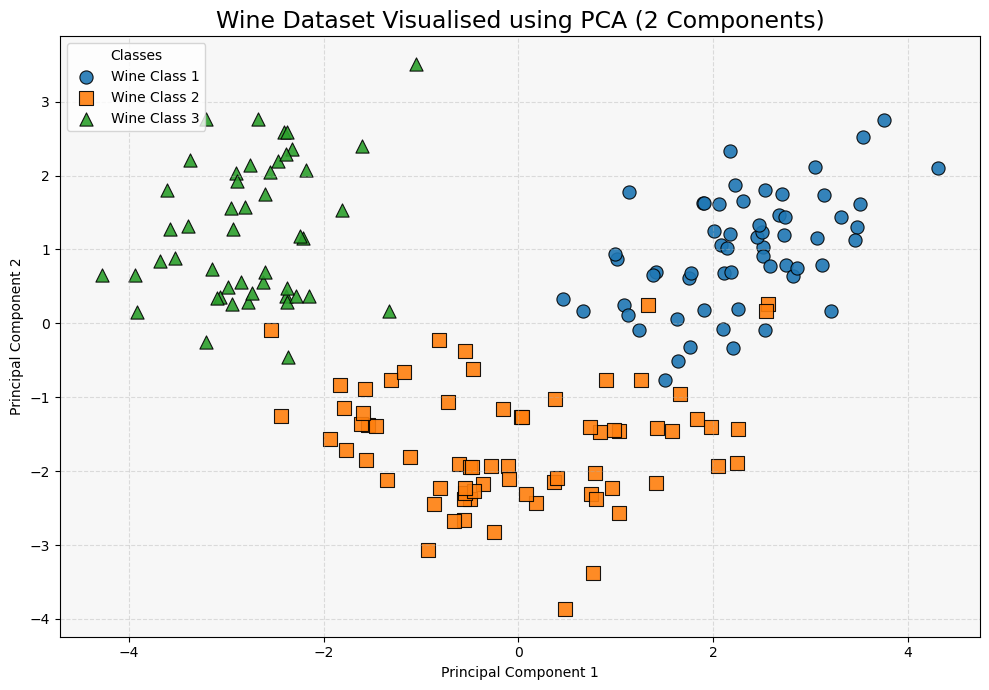

In [7]:
plt.figure(figsize=(10, 7), facecolor='white')

ax = plt.gca()
ax.set_facecolor('#f7f7f7')

markers = ['o', 's', '^']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, cls in enumerate(np.unique(y)):
    plt.scatter(
        X_pca[y == cls, 0],
        X_pca[y == cls, 1],
        label=f'Wine Class {cls}',
        marker=markers[i],
        s=90,
        color=colors[i],
        edgecolors='black',
        linewidths=0.8,
        alpha=0.9
    )

plt.title('Wine Dataset Visualised using PCA (2 Components)', fontsize=17)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Classes')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('wine_pca_plot.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)


Training set shape: (124, 2)
Testing set shape: (54, 2)


In [9]:
models = {
    'Linear': SVC(kernel='linear', C=1.0),
    'Polynomial': SVC(kernel='poly', degree=3, C=1.0, gamma='scale'),
    'RBF': SVC(kernel='rbf', C=1.0, gamma='scale')
}


In [10]:
def plot_boundary_with_support_vectors(model, X, y, title, filename):
    x_min, x_max = X[:, 0].min() - 1.2, X[:, 0].max() + 1.2
    y_min, y_max = X[:, 1].min() - 1.2, X[:, 1].max() + 1.2

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 700),
        np.linspace(y_min, y_max, 700)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('#eef2f7')

    ax.contourf(xx, yy, Z, levels=20, alpha=0.15, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8, alpha=0.4)

    markers = ['o', 's', '^']
    colors = ['#3b82f6', '#f97316', '#22c55e']

    for i, cls in enumerate(np.unique(y)):
        ax.scatter(
            X[y == cls, 0],
            X[y == cls, 1],
            label=f'Wine Class {cls}',
            marker=markers[i],
            s=90,
            color=colors[i],
            edgecolors='black',
            linewidths=0.7,
            alpha=0.9
        )

    ax.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=200,
        facecolors='none',
        edgecolors='black',
        linewidths=1.5,
        label='Support Vectors'
    )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.legend(frameon=True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()


Linear Kernel Accuracy: 0.9444


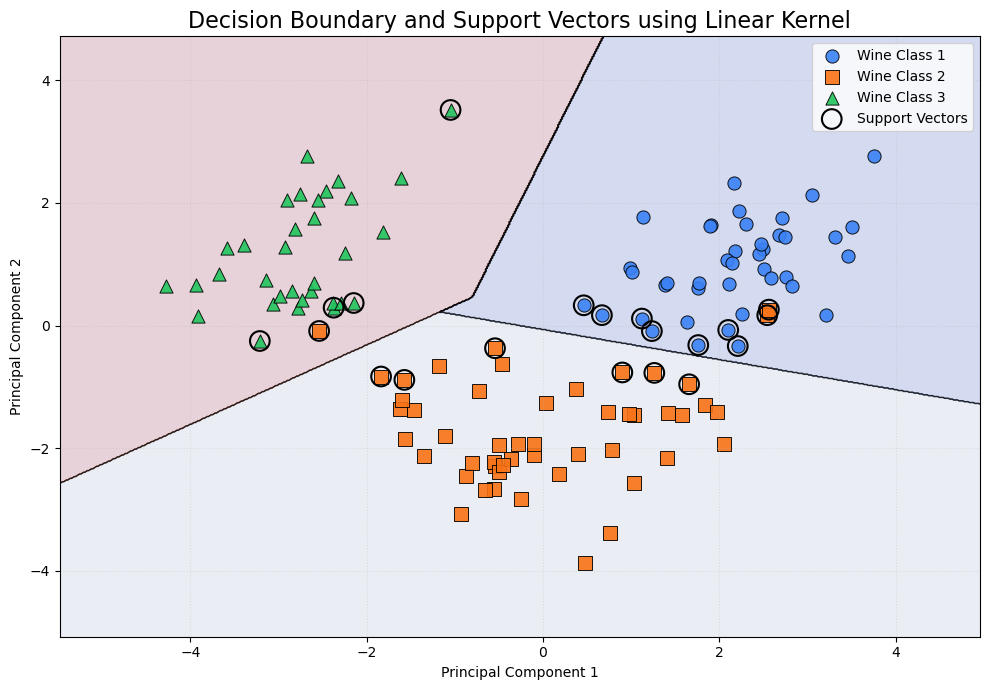

Polynomial Kernel Accuracy: 0.9074


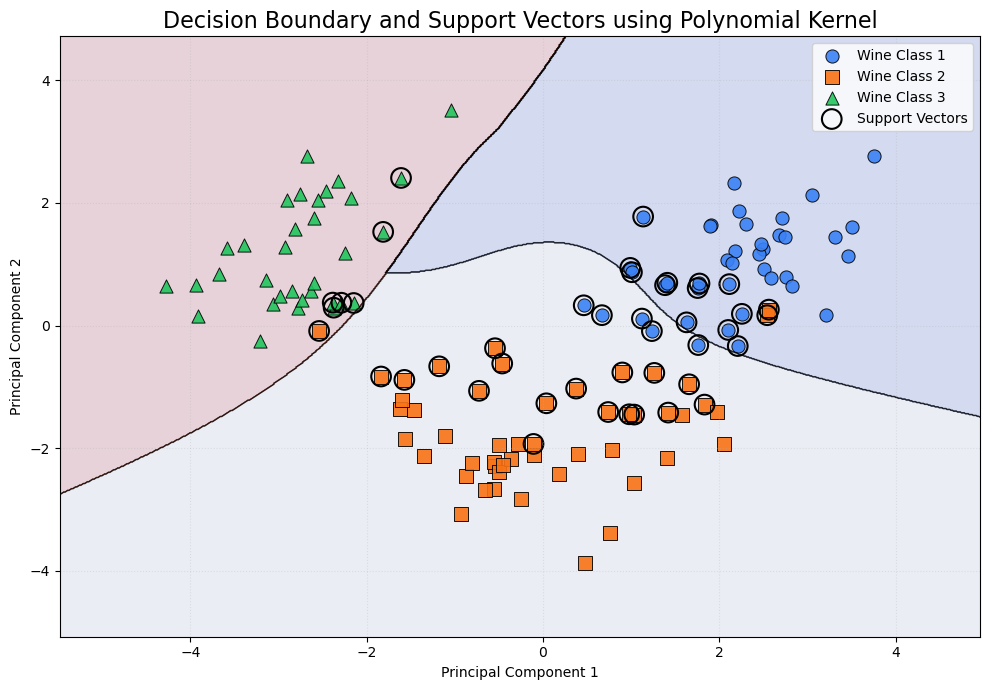

RBF Kernel Accuracy: 0.9630


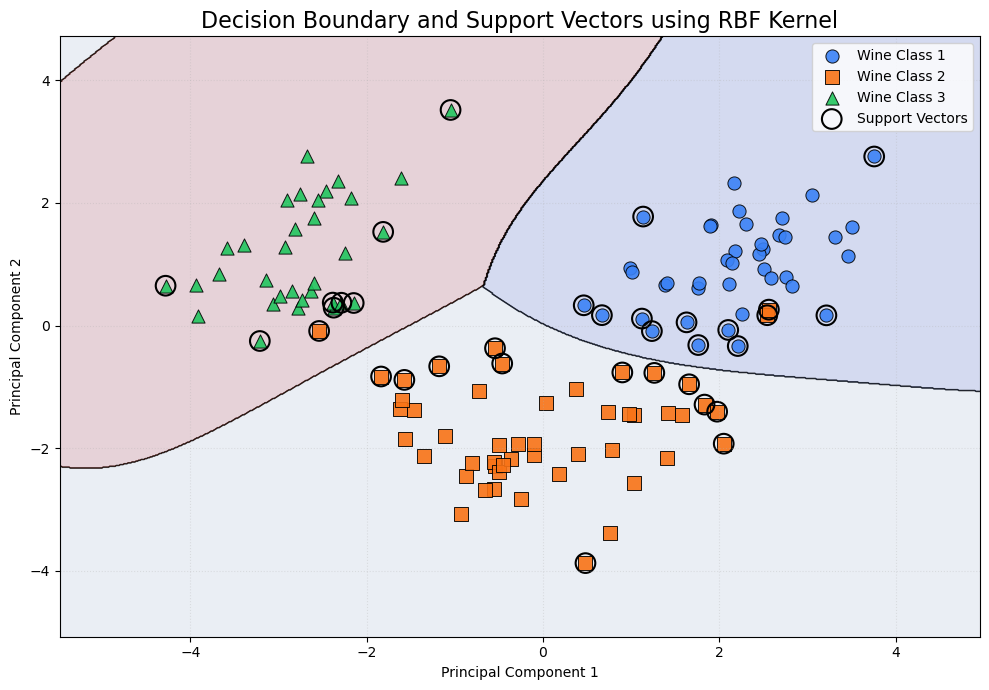

In [11]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f'{name} Kernel Accuracy: {acc:.4f}')
    results.append((name, acc))

    plot_boundary_with_support_vectors(
        model,
        X_train,
        y_train,
        f'Decision Boundary and Support Vectors using {name} Kernel',
        f'{name.lower()}_support_vectors_wine.png'
    )


In [12]:
results_df = pd.DataFrame(results, columns=['Kernel', 'Accuracy'])
results_df


,Kernel,Accuracy
0,Linear,0.944444
1,Polynomial,0.907407
2,RBF,0.962963


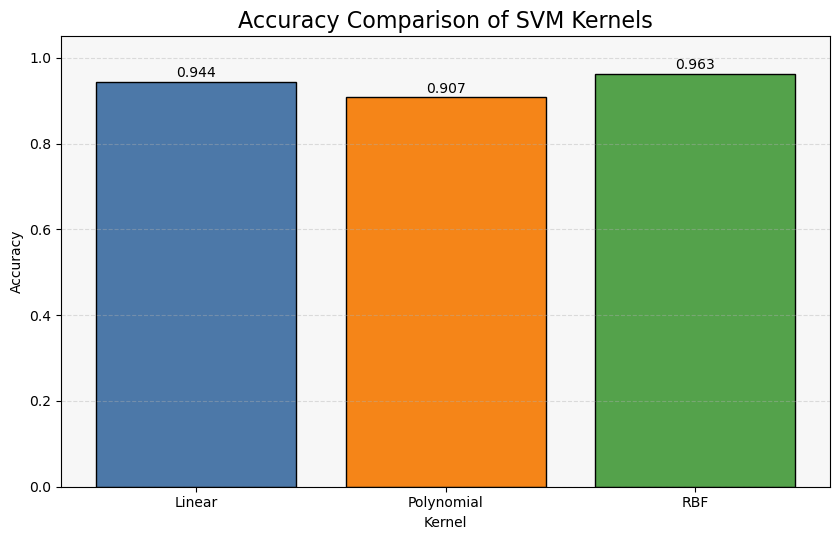

In [13]:
plt.figure(figsize=(8.5, 5.5), facecolor='white')

ax = plt.gca()
ax.set_facecolor('#f7f7f7')

bars = plt.bar(
    results_df['Kernel'],
    results_df['Accuracy'],
    color=['#4c78a8', '#f58518', '#54a24b'],
    edgecolor='black'
)

plt.title('Accuracy Comparison of SVM Kernels', fontsize=16)
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f'{height:.3f}',
        ha='center'
    )

plt.tight_layout()
plt.savefig('kernel_accuracy_comparison_wine.png', dpi=300, bbox_inches='tight')
plt.show()


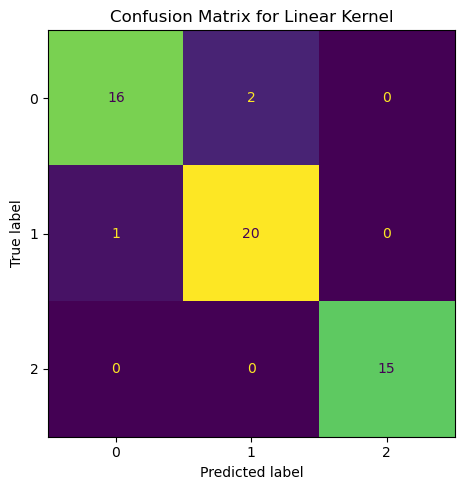

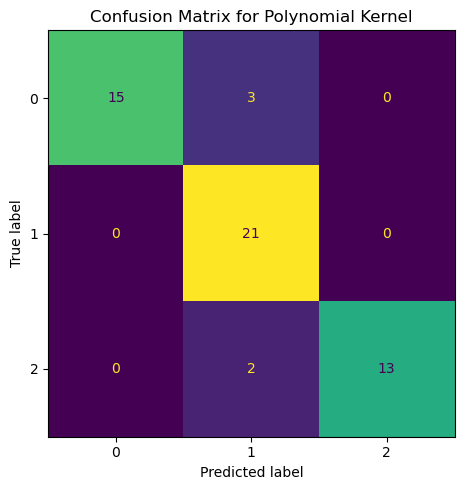

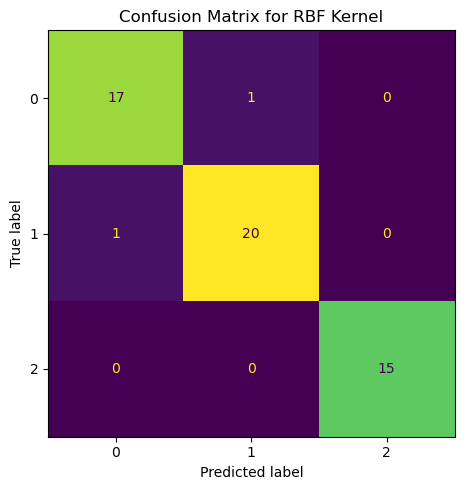

In [14]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')
    ax.set_facecolor('#f7f7f7')

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)

    plt.title(f'Confusion Matrix for {name} Kernel')
    plt.tight_layout()
    plt.show()


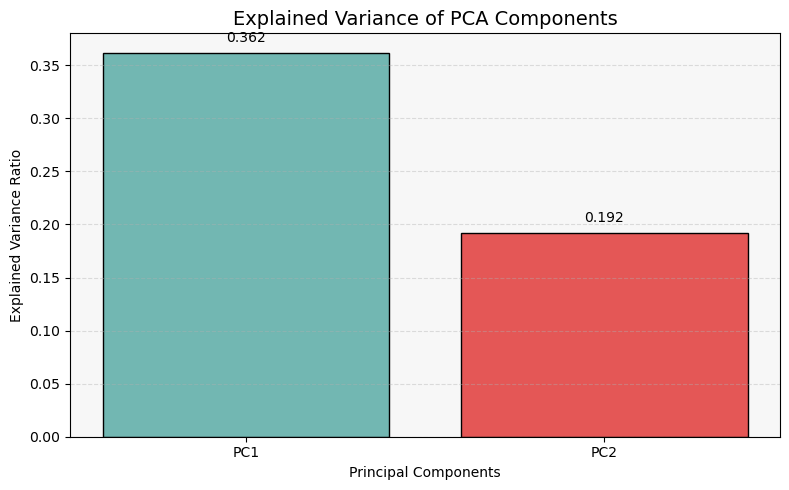

In [15]:
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5), facecolor='white')

ax = plt.gca()
ax.set_facecolor('#f7f7f7')

bars = plt.bar(
    ['PC1', 'PC2'],
    explained_var,
    color=['#72b7b2', '#e45756'],
    edgecolor='black'
)

plt.title('Explained Variance of PCA Components', fontsize=14)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.3f}',
        ha='center'
    )

plt.tight_layout()
plt.savefig('pca_explained_variance_wine.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
print('Final Results Summary')
print(results_df)


Final Results Summary
       Kernel  Accuracy
0      Linear  0.944444
1  Polynomial  0.907407
2         RBF  0.962963


In [17]:
best_kernel = results_df.loc[results_df['Accuracy'].idxmax()]
print('Best performing kernel:')
print(best_kernel)


Best performing kernel:
Kernel           RBF
Accuracy    0.962963
Name: 2, dtype: object
